This example shows the full implementation of the software package to capture and plot experimental data.

In [1]:
# Necessary so that changes to an imported module will be seen by the next import statement
# https://stackoverflow.com/questions/64158622/jupyter-does-not-see-changes-in-the-imported-module
%load_ext autoreload
%autoreload 2

In [2]:
from oligo_maldi.experiment import Experiment
from oligo_maldi.metadata import Enzyme
from oligo_maldi.analytes import Oligo
from oligo_maldi.quant import *
from oligo_maldi.helper import *

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


In [3]:
data = "/Users/mitchsyberg-olsen/github/oligo_maldi/data/experiment_2"
run1 = Experiment(data_folder=data)

In this experiment, we are expecting oligos to be polymerized and 5'phosphorylated.
This can be captured using Oligo objects with various sequences and 5' ends.

In [4]:
# Substrate oligos
oligo_1H_v1 = 'GGGAGACCACAACG'
v1_starter = [Oligo(name=f"Oligo, {end}", seq=oligo_1H_v1, five_prime_end=end) for end in ['OH', 'P', 'PP', 'PPP']]

# polymerization
ends = ['P', 'PP', 'PPP']       # possible 5' end chemistries
pol_events = 3                 # maximum number of polymerizations to check
dntps = ['A', 'T', 'C', 'G']    # dNTPs to use

v1_products = {}
for dntp in dntps:
        for i in range(1, pol_events + 1):
            for end in ends:
                pol = dntp * i
                seq = pol + oligo_1H_v1
                key = f"+{pol}, {end}"
                value = Oligo(name=key, seq=seq, five_prime_end=end)
                v1_products[key] = value

In [5]:
v1_products

{'+A, P': <oligo_maldi.oligo.Oligo at 0x10f9c5940>,
 '+A, PP': <oligo_maldi.oligo.Oligo at 0x10ff1f890>,
 '+A, PPP': <oligo_maldi.oligo.Oligo at 0x10f99dae0>,
 '+AA, P': <oligo_maldi.oligo.Oligo at 0x10f99d8c0>,
 '+AA, PP': <oligo_maldi.oligo.Oligo at 0x10f9b5a50>,
 '+AA, PPP': <oligo_maldi.oligo.Oligo at 0x10f9b4950>,
 '+AAA, P': <oligo_maldi.oligo.Oligo at 0x10ff2c7d0>,
 '+AAA, PP': <oligo_maldi.oligo.Oligo at 0x10ff2c8c0>,
 '+AAA, PPP': <oligo_maldi.oligo.Oligo at 0x10ff84130>,
 '+T, P': <oligo_maldi.oligo.Oligo at 0x10ff84c90>,
 '+T, PP': <oligo_maldi.oligo.Oligo at 0x1501cc600>,
 '+T, PPP': <oligo_maldi.oligo.Oligo at 0x10f93bb90>,
 '+TT, P': <oligo_maldi.oligo.Oligo at 0x10f93bd10>,
 '+TT, PP': <oligo_maldi.oligo.Oligo at 0x10f936f10>,
 '+TT, PPP': <oligo_maldi.oligo.Oligo at 0x10f937120>,
 '+TTT, P': <oligo_maldi.oligo.Oligo at 0x10ff63430>,
 '+TTT, PP': <oligo_maldi.oligo.Oligo at 0x10ff636b0>,
 '+TTT, PPP': <oligo_maldi.oligo.Oligo at 0x103489c70>,
 '+C, P': <oligo_maldi.oligo

Define numerical codes that correspond to enzyme mutations

In [6]:
# Enzymes
enz_codes = {
    0: 'Base (S82A)',
    15: 'A107M',
    16: 'D139W',
    17: 'D55H',
    18: 'D83E',
    19: 'E102W',
    20: 'E64D',
    21: 'E99V',
    23: 'G100F',
    25: 'H54S',
    27: 'I116L',
    29: 'K138S',
    30: 'K248F',
    31: 'L148P',
    32 : 'L162E',
    33: 'L172R',
    34: 'L199H',
    35: 'M24L',
    37: 'N187G',
    38: 'N202D',
    39: 'R226G',
    40: 'S120C',
    41: 'S124C',
    42: 'T239N'
}

Define which wells contain which enzyme

In [7]:
enz_rows = {
    # first chunk
    0: ['A','B'],
    15: ['C','D'],
    16: ['E','F'],
    17: ['G','H'],
    18: ['I','J'],
    19: ['K','L'],
    20: ['M','N'],
    21: ['O','P'],
    # second chunk
    23: ['A','B'],
    25: ['C','D'],
    27: ['E','F'],
    29: ['G','H'],
    30: ['I','J'],
    31: ['K','L'],
    32: ['M','N'],
    33: ['O','P'],
    # third chunk
    34: ['A','B'],
    35: ['C','D'],
    37: ['E','F'],
    38: ['G','H'],
    39: ['I','J'],
    40: ['K','L'],
    41: ['M','N'],
    42: ['O','P'],
}

enz_cols = {
    # first chunk
    0: list(range(0,9)),
    15: list(range(0,9)),
    16: list(range(0,9)),
    17: list(range(0,9)),
    18: list(range(0,9)),
    19: list(range(0,9)),
    20: list(range(0,9)),
    21: list(range(0,9)),
    #second chunk
    23: list(range(9,17)),
    25: list(range(9,17)),
    27: list(range(9,17)),
    29: list(range(9,17)),
    30: list(range(9,17)),
    31: list(range(9,17)),
    32: list(range(9,17)),
    33: list(range(9,17)),
    # third chunk
    34: list(range(17,25)),
    35: list(range(17,25)),
    37: list(range(17,25)),
    38: list(range(17,25)),
    39: list(range(17,25)),
    40: list(range(17,25)),
    41: list(range(17,25)),
    42: list(range(17,25))
}

Define which wells receive which nucleotide for polymerization

In [8]:
# dNTPs
dntp_cols = {
    'G': [1,2,  9,10, 17,18],
    'C': [3,4, 11,12, 19,20],
    'A': [5,6, 13,14, 21,22],
    'T': [7,8, 15,16, 23,24]
}

It is also possible to exclude samples dynamically during data processing, using the Experiment.exclude attribute
Excluded wells will not show up in plate maps, or in the final excel outputs

In [9]:
run1.exclude = ['B5', 'D5', 'F5','H5','J5','L5','N5','P5']  # pipetting error on these wells

Incorporate all of the above information into Experiment

In [10]:
# reset mois
for sample in run1.samples.values():
    sample.analytes = []

# annotate samples with enzyme, NTPs, and MOIs
for sample_key in run1.samples.keys():
    if sample_key in run1.exclude:
        pass
    else:
        try:
            enz_id = key_to_enz_code(key=sample_key, enz_rows=enz_rows, enz_cols=enz_cols)
            enz = Enzyme(id=enz_id, name="DdiTLP4 (S82A)", mutation=enz_codes[enz_id])
            ntp = key_to_dntp(key=sample_key, dntp_cols=dntp_cols)
            mois = [o for o in v1_products.values() if ntp in o.name]

            run1.samples[sample_key].enzyme = enz
            run1.samples[sample_key].ntp = ntp
            run1.samples[sample_key].name = ", ".join([sample_key, str(enz.id), enz.mutation, ntp])
            run1.samples[sample_key].analytes.extend(v1_starter)
            run1.samples[sample_key].analytes.extend(mois)

        except IndexError:
            pass


Now, Experiment.show_sample_positions() is very helpful

(<Figure size 1200x1800 with 1 Axes>, <Axes: >)

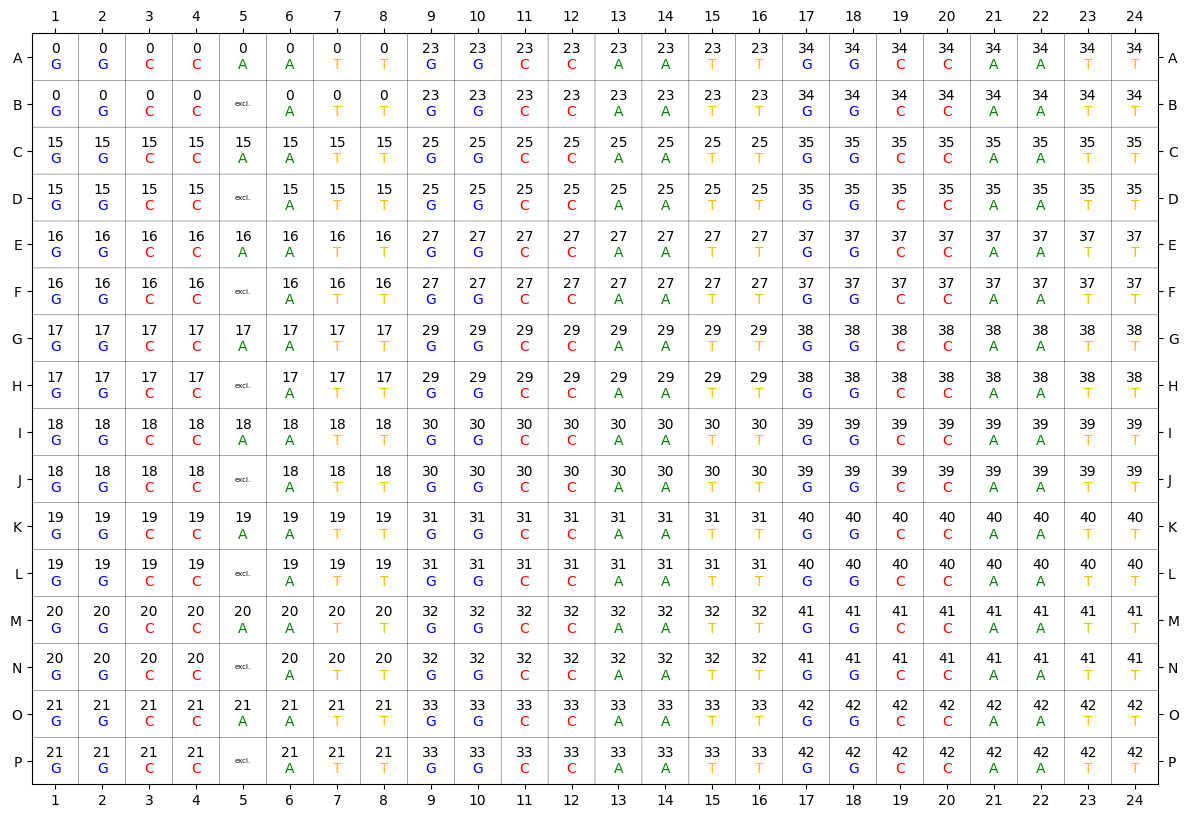

In [11]:
run1.show_sample_positions()

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Per sample signal intensity distribution'}, xlabel='Percent of data', ylabel='Relative signal'>)

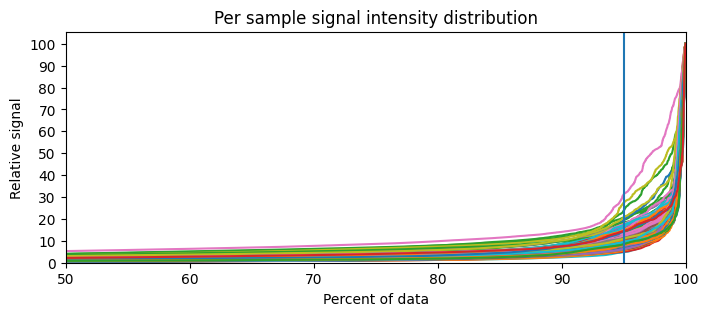

In [12]:
run1.sorted_signal_plot()

(<Figure size 640x480 with 2 Axes>, <Axes: title={'center': 'Signal / Noise'}>)

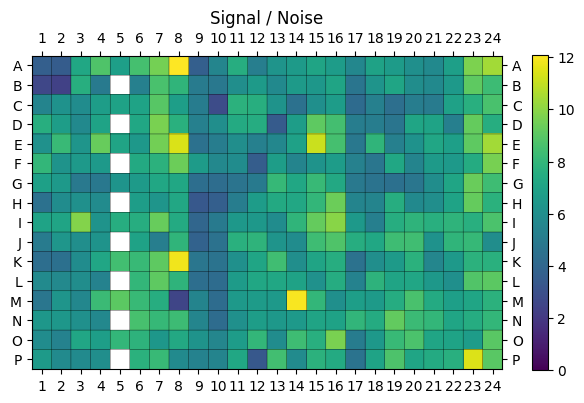

In [13]:
run1.heatmap(numerator='Oligo, PP', denominator='noise', title="Signal / Noise")

For example, overlay all reactions where dCTP was included in the reaction

(<Figure size 1200x200 with 1 Axes>, <Axes: xlabel='m/z'>)

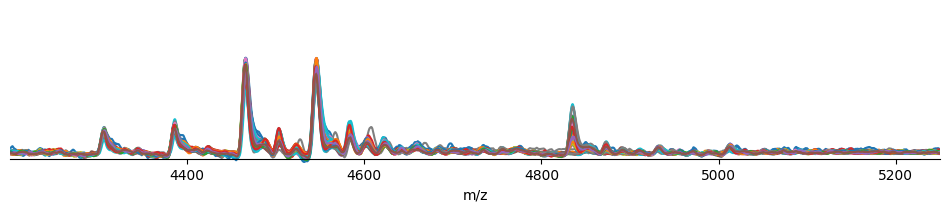

In [14]:
c_keys = [k for k in run1.samples.keys() if key_to_dntp(k, dntp_cols) == 'C']
run1.stacked_plot(wells=c_keys, xlim=[4200,5250], overlay=True, label=False, figsize=(12,2))

(<Figure size 1200x200 with 2 Axes>,
 array([<Axes: >, <Axes: xlabel='m/z'>], dtype=object))

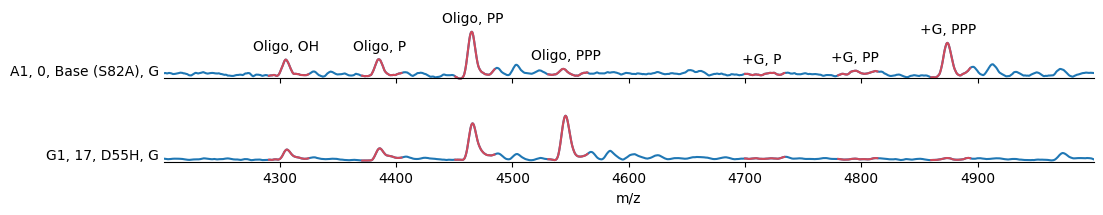

In [15]:
run1.stacked_plot(wells=['A1','G1'], xlim=[4200,5000], label_first_only=True)

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='m/z'>], dtype=object))

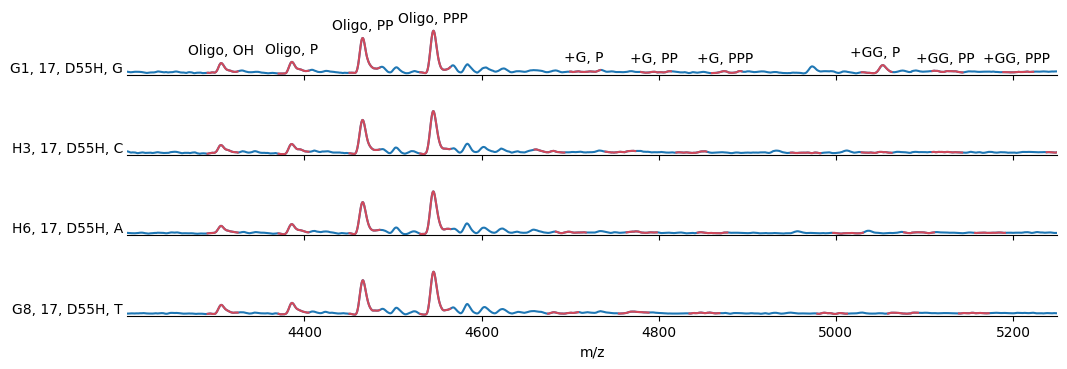

In [16]:
run1.stacked_plot(wells=['G1', 'H3', 'H6', 'G8'], xlim=[4200,5250])

In [18]:
outfile = "/Users/mitchsyberg-olsen/github/oligo_maldi/demos/quant_demo_results_5.xlsx"
run1.write_to_excel(filename=outfile,overwrite=False)

Quantitative plotting section

In [19]:
df = pd.read_excel(outfile, sheet_name='filtered', header=0)

Define experimental information that will affect the downstream analysis

In [20]:
pol = [1, 2, 3]
phos = ['P', 'PP', 'PPP']
nucleotides = ['A', 'C', 'G', 'T']

# basically converts '+A, PPP' to '+N, PPP' etc
mapping_dict = {}
for po in pol:
    for ph in phos:
        mapping_dict[f"+{'N'*po}, {ph}"] = [f'+{N*po}, {ph}' for N in nucleotides]

df_variables = {'unreacted': 'Oligo, PPP',
                'correct': '+N, PPP'}

other_variables = {'a1': 1,
                   'a2': 2,
                   'b1': 2,
                   'b2': 2}

irrelevant_mois = ['Oligo, OH', 'Oligo, P', 'Oligo, PP',    # these are impurities in the starting material that we can ignore
                   '+N, PP', '+NN, PP', '+NNN, PP', # we don't care about diphosphate species right now
                   '+NN, P','+NNN, P']  # weird blips in certain mass spectra corresponding to these

colours_long = ['lighter grey', 'light blue', 'dark blue', 'light red', 'dark red']
colours_long = [colour_dict[key] for key in colours_long]

Main data processing step

In [21]:
plotter = DataProcessor(dataframes={'df1': df},
                        attributes=['enz_name','enz_id','enz_mutation','ntp'],
                        exclude_mois=irrelevant_mois,
                        collapse_mois=mapping_dict,
                        activity_scoring_function=Enzyme.default_activity_score,
                        activity_scoring_df_variables=df_variables,
                        activity_scoring_other_variables=other_variables)

In [22]:
outfile = "/Users/mitchsyberg-olsen/github/oligo_maldi/demos/quant_demo_results_2.xlsx"
plotter.write_to_excel(filename=outfile, overwrite=True)

<Axes: title={'center': 'dGTP'}, ylabel='Signal intensity (au)'>

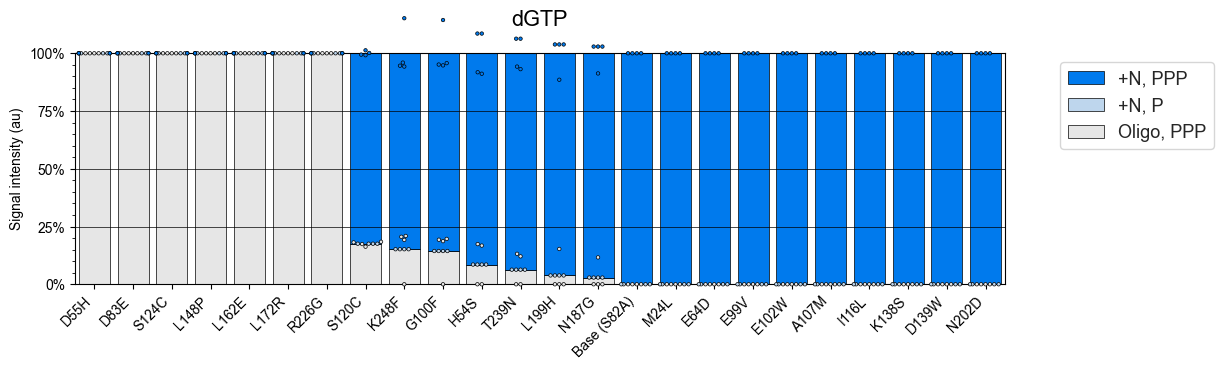

In [36]:
ntp = 'G'
plotter.stacked_bar(global_var=('ntp', ntp),
                    x_category='enz_mutation',
                    y_species=['Oligo, PPP', '+N, P', '+N, PPP'],
                    y_colours=colours_long,
                    sort_by=['Oligo, PPP', '+N, P'],
                    sort_order='descending',
                    title=f"d{ntp}TP",
                    figsize=(12,3))

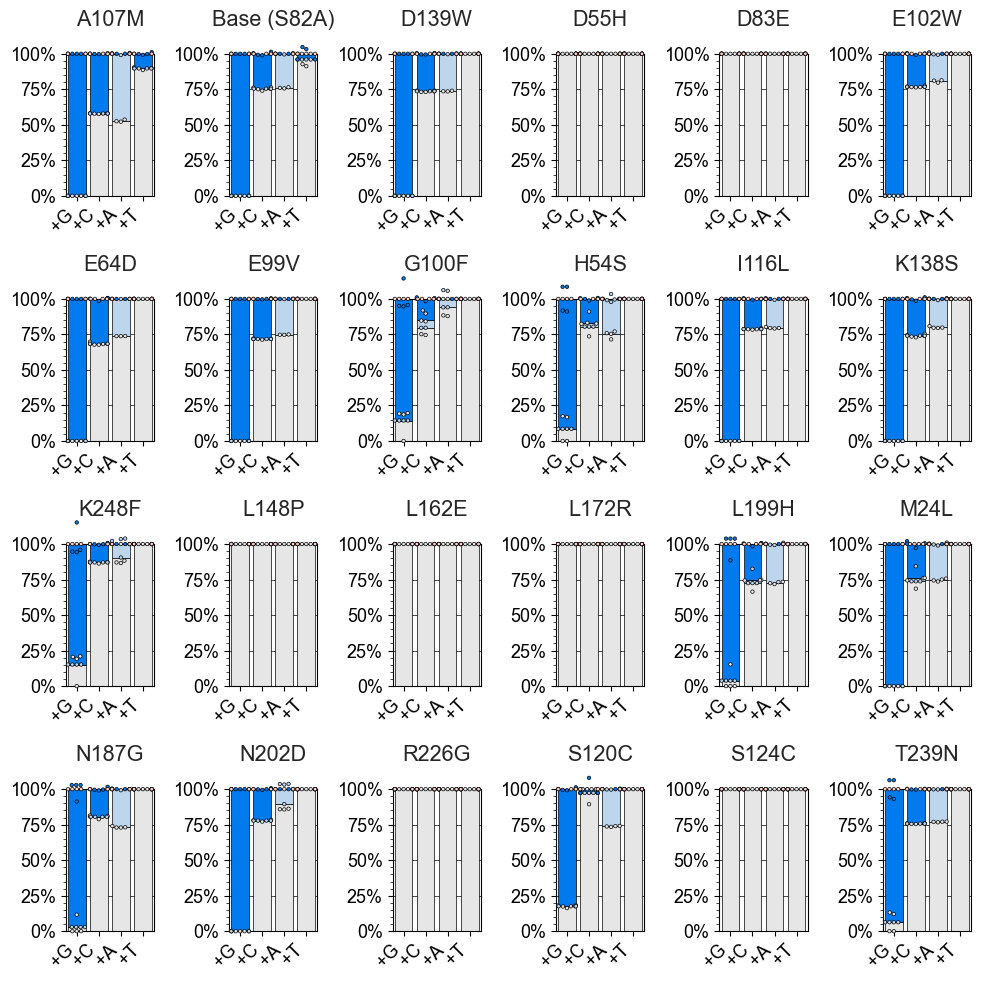

In [38]:
fig, axs = plt.subplots(nrows=4, ncols=6, figsize=(10,10))
axs = axs.flatten()

enz_order = sorted(plotter.data_ungrouped['enz_mutation'].unique().tolist())

for i, enz in enumerate(enz_order):
    plotter.stacked_bar(global_var=('enz_mutation', enz),
                        x_category='ntp',
                        x_labels=['G','C','A','T'],
                        x_labels_overwrite=['+G','+C','+A','+T'],
                        y_species=['Oligo, PPP', '+N, P', '+N, PPP', '+NN, PPP'],
                        y_colours=colours_long,
                        title=enz,
                        show_legend=False,
                        ax=axs[i])
for ax in axs:
    if not ax.has_data():
        ax.remove()
    else:
        ax.set_ylabel(None)

plt.tight_layout()